# Q1 — Cite the source used

> **Source used for the Gradient Descent reference:**  
> Sagar Mainkar, *"Linear Regression using Gradient Descent in Python"* (GitHub Gist)  
> [https://gist.github.com/sagarmainkar/41d135a04d7d3bc4098f0664fe20cf3c](https://gist.github.com/sagarmainkar/41d135a04d7d3bc4098f0664fe20cf3c)


In [8]:
# Q1 — Print the citation
citation = (
    "Source used for the Gradient Descent reference:\n"
    "Sagar Mainkar, 'Linear Regression using Gradient Descent in Python' (GitHub Gist)\n"
    "https://gist.github.com/sagarmainkar/41d135a04d7d3bc4098f0664fe20cf3c"
)
print(citation)


Source used for the Gradient Descent reference:
Sagar Mainkar, 'Linear Regression using Gradient Descent in Python' (GitHub Gist)
https://gist.github.com/sagarmainkar/41d135a04d7d3bc4098f0664fe20cf3c


# Q2 — Gradient Descent on Raw Data (No Standardization)

We apply batch Gradient Descent on the original (raw-scale) dataset to illustrate non-convergence:

- Model: **Crimes = β₀ + β₁ × Temperature_F**
- Learner: **Batch Gradient Descent** using `np.matmul`
- Learning rates: **0.1**, **0.01**, **0.001**
- Iterations: **1000**
- Missing values: **Drop missing rows before fitting**
- Plots: **Three scatterplots** of iterations (x) vs loss (y), one for each learning rate

This step demonstrates that Gradient Descent may **fail to converge** on raw (unstandardized) data.


[LR=0.1] Diverged at iteration 55. Stopping early.


/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_56979/1567770647.py:24: RuntimeWarning: overflow encountered in matmul
  loss = (1.0 / (2 * n)) * np.matmul(residuals.T, residuals)[0, 0]


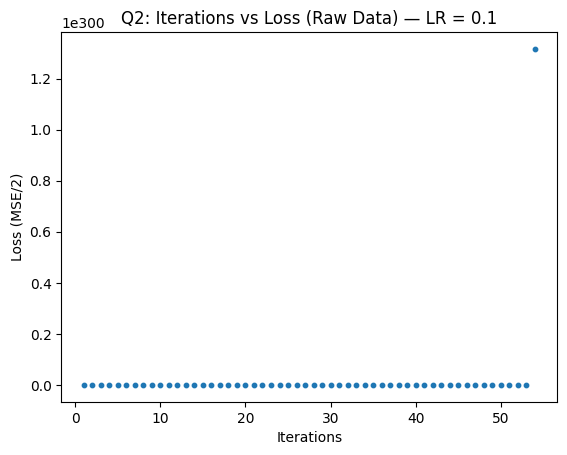

[LR=0.01] Diverged at iteration 86. Stopping early.


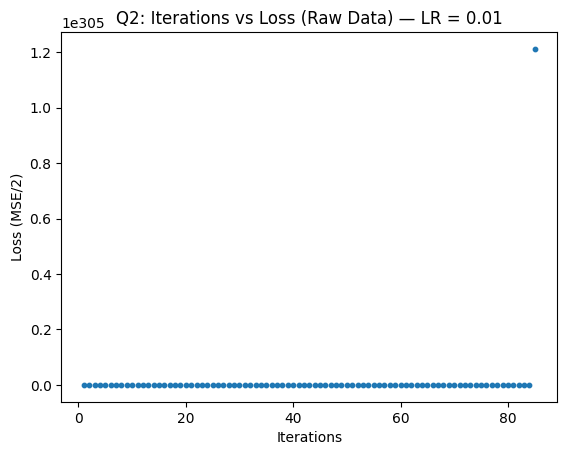

[LR=0.001] Diverged at iteration 208. Stopping early.


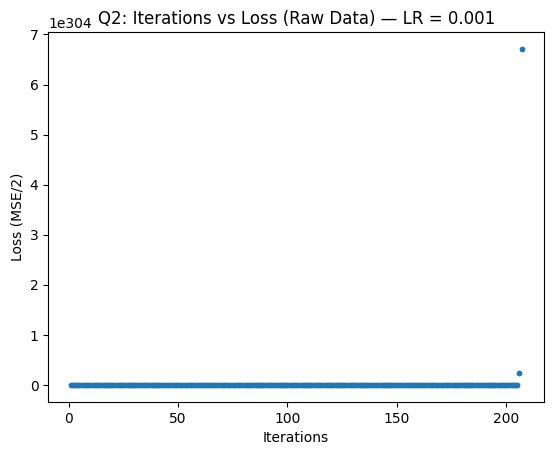

LR=0.1 | beta0=-1.606224451921033e+149, beta1=-1.2971041168645079e+151, final_loss=inf
LR=0.01 | beta0=4.8060693896358036e+150, beta1=3.881134036888375e+152, final_loss=inf
LR=0.001 | beta0=3.0663720843510424e+149, beta1=2.4762441199878335e+151, final_loss=inf


In [9]:
# Q2 — Gradient Descent on Raw Data with missing values dropped + scatter plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load and drop missing values (per PDF: drop the 2 missing values)
df = pd.read_excel("crimes.xlsx")  # same folder as the notebook
df = df.dropna().reset_index(drop=True)

# 2) Prepare raw X (with intercept) and y
X_raw = df[["Temperature_F"]].to_numpy(dtype=np.float64)
y_raw = df["Crimes"].to_numpy(dtype=np.float64).reshape(-1, 1)
ones = np.ones((X_raw.shape[0], 1), dtype=np.float64)
X_raw_i = np.concatenate([ones, X_raw], axis=1)  # shape: (n, 2)

# 3) Batch Gradient Descent using np.matmul
def gradient_descent(X, y, lr=0.01, n_iter=1000):
    n, p = X.shape
    beta = np.zeros((p, 1), dtype=np.float64)
    losses = []
    for it in range(1, n_iter + 1):
        y_hat = np.matmul(X, beta)              # REQUIRED: np.matmul
        residuals = y_hat - y
        loss = (1.0 / (2 * n)) * np.matmul(residuals.T, residuals)[0, 0]
        losses.append(loss)

        # Guard for divergence to keep plots meaningful
        if not np.isfinite(loss):
            print(f"[LR={lr}] Diverged at iteration {it}. Stopping early.")
            break

        grad = (1.0 / n) * np.matmul(X.T, residuals)  # REQUIRED: np.matmul
        beta = beta - lr * grad
    return beta, np.array(losses, dtype=np.float64)

# 4) Run for the three learning rates with 1000 target iterations (early-stop on divergence)
lrs = [0.1, 0.01, 0.001]
results_raw = {}

for lr in lrs:
    beta, losses = gradient_descent(X_raw_i, y_raw, lr=lr, n_iter=1000)
    results_raw[lr] = (beta, losses)

    # Scatter plot (to match the PDF's example style)
    plt.figure()
    iters = np.arange(1, len(losses) + 1)
    plt.scatter(iters, losses, s=10)  # small dots
    plt.xlabel("Iterations")
    plt.ylabel("Loss (MSE/2)")
    plt.title(f"Q2: Iterations vs Loss (Raw Data) — LR = {lr}")
    plt.show()

# 5) Print a concise summary (final beta and loss for each LR)
for lr in lrs:
    beta, losses = results_raw[lr]
    final_loss = losses[-1] if len(losses) > 0 else np.nan
    print(f"LR={lr} | beta0={beta[0,0]}, beta1={beta[1,0]}, final_loss={final_loss}")


# Q3 — Standardize X and Y Variables

Standardize both **X** (`Temperature_F`) and **Y** (`Crimes`) using the z-score:

\[
Z = \frac{x - \bar{x}}{s}
\]

- Add a column of 1’s to **X** as the intercept term.
- **Do not standardize the column of 1’s.**


In [10]:
# Q3 — Standardize X and Y (z-score) and add an unstandardized intercept column
import numpy as np
import pandas as pd

# Load data from the same folder
df = pd.read_excel("crimes.xlsx").dropna().reset_index(drop=True)

# Original arrays
X = df[["Temperature_F"]].to_numpy(dtype=float)     # shape: (n, 1)
y = df["Crimes"].to_numpy(dtype=float).reshape(-1, 1)

# Means and standard deviations
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0, ddof=0)
y_mean = y.mean(axis=0)
y_std  = y.std(axis=0, ddof=0)

# Standardize X and Y
X_z = (X - X_mean) / X_std
y_z = (y - y_mean) / y_std

# Add intercept column of 1's (do not standardize it)
ones = np.ones((X_z.shape[0], 1))
Xz_i = np.concatenate([ones, X_z], axis=1)

# Quick sanity checks/peek
print("X mean/std:", X_mean[0], X_std[0])
print("y mean/std:", y_mean[0], y_std[0])
print("First 5 rows of standardized X (with intercept):")
print(Xz_i[:5])
print("First 5 rows of standardized y:")
print(y_z[:5])


X mean/std: 79.40449438202248 10.35571719761286
y mean/std: 29.382022471910112 4.018232654092637
First 5 rows of standardized X (with intercept):
[[ 1.         -0.42532007]
 [ 1.         -1.58410027]
 [ 1.          0.54033009]
 [ 1.          0.25063504]
 [ 1.         -1.29440522]]
First 5 rows of standardized y:
[[ 0.402659  ]
 [-1.33940041]
 [ 0.15379337]
 [-0.59280352]
 [-2.0859973 ]]


# Q4 — Compare Statsmodels OLS and Gradient Descent on Standardized Data

We now use **standardized X and Y** to estimate regression coefficients:

1. Use `statsmodels.OLS` to calculate coefficients on the standardized data.  
2. Run our Gradient Descent (using `np.matmul`) again with learning rates **0.01** and **0.001**.  
3. Compare both sets of coefficients to see how similar they are.


OLS coefficients on standardized inputs [intercept, slope]:
[6.93889390e-17 8.23085432e-01]

Learning Rate = 0.01
GD coefficients: intercept=0.000000, slope=0.823085
Difference (GD - OLS): intercept=0.000000, slope=-0.000000
Final Loss: 0.161265

Learning Rate = 0.001
GD coefficients: intercept=0.000000, slope=0.711804
Difference (GD - OLS): intercept=0.000000, slope=-0.111281
Final Loss: 0.167469


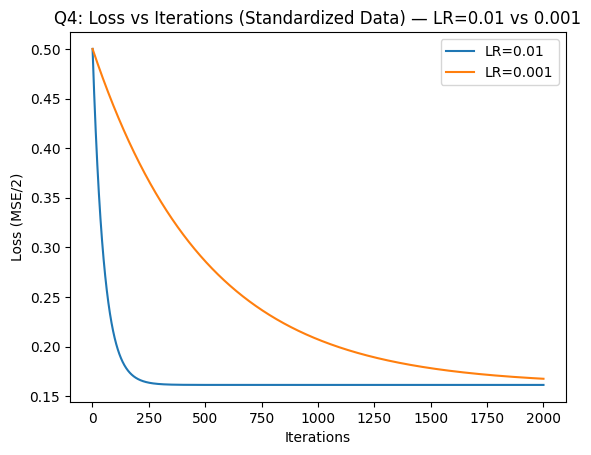

In [11]:
# Q4 — Compare Statsmodels OLS vs Gradient Descent on standardized inputs
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Reuse Xz_i (standardized X with intercept) and y_z from Q3
# 1. OLS using statsmodels
ols_model = sm.OLS(y_z, Xz_i).fit()
beta_ols = ols_model.params.reshape(-1, 1)
print("OLS coefficients on standardized inputs [intercept, slope]:")
print(beta_ols.ravel())

# 2. Define Gradient Descent function (using np.matmul)
def gradient_descent(X, y, lr=0.01, n_iter=2000):
    n, p = X.shape
    beta = np.zeros((p, 1))
    losses = []
    for it in range(n_iter):
        y_hat = np.matmul(X, beta)
        residuals = y_hat - y
        loss = (1/(2*n)) * np.matmul(residuals.T, residuals)[0, 0]
        losses.append(loss)
        grad = (1/n) * np.matmul(X.T, residuals)
        beta = beta - lr * grad
    return beta, np.array(losses)

# 3. Run Gradient Descent with two learning rates
lrs_std = [0.01, 0.001]
results_std = {}

for lr in lrs_std:
    beta_gd, losses = gradient_descent(Xz_i, y_z, lr=lr, n_iter=2000)
    results_std[lr] = (beta_gd, losses)
    diff = beta_gd - beta_ols
    print(f"\nLearning Rate = {lr}")
    print(f"GD coefficients: intercept={beta_gd[0,0]:.6f}, slope={beta_gd[1,0]:.6f}")
    print(f"Difference (GD - OLS): intercept={diff[0,0]:.6f}, slope={diff[1,0]:.6f}")
    print(f"Final Loss: {losses[-1]:.6f}")

# 4. Optional: plot both losses together to observe convergence speed
plt.figure()
for lr in lrs_std:
    plt.plot(np.arange(1, len(results_std[lr][1]) + 1), results_std[lr][1], label=f"LR={lr}")
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE/2)")
plt.title("Q4: Loss vs Iterations (Standardized Data) — LR=0.01 vs 0.001")
plt.legend()
plt.show()


# Q5 — Plot Loss Functions for Both Learning Rates on the Same Graph

Finally, plot the **loss (cost) function** values over the iterations for both learning rates  
(**0.01** and **0.001**) on the same chart.

This visual comparison shows that:
- The higher learning rate (**0.01**) converges faster.
- The lower learning rate (**0.001**) converges more slowly but smoothly.


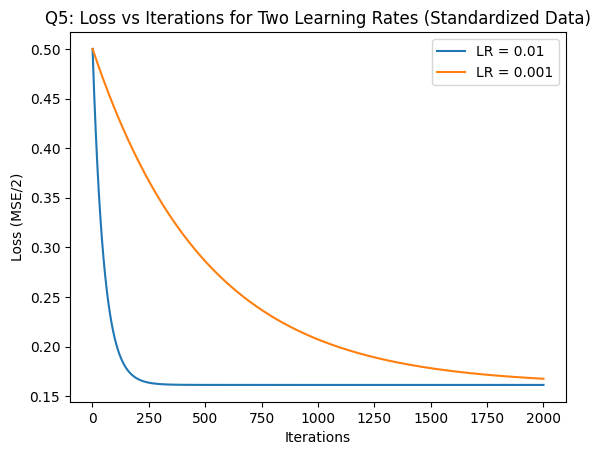

In [12]:
# Q5 — Plot both loss curves on one graph
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
for lr in [0.01, 0.001]:
    losses = results_std[lr][1]
    plt.plot(np.arange(1, len(losses) + 1), losses, label=f"LR = {lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss (MSE/2)")
plt.title("Q5: Loss vs Iterations for Two Learning Rates (Standardized Data)")
plt.legend()
plt.show()
